In [2]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier             # no effect after transfomation

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer


## Power Transformer
# 1. box-coc
#  2. yeo-johnson

*  1. Boc-Cox
* *  Condition for boc-cox : values > 0
*  (Xi)^b = (Xi ^b - 1 )/ b       , if b != 0
*          = ln(Xi)                , if b = 0
*   b value lie btw [-5,5] The exponent here is a variable called lambda (b) that varies
*  over range -5 to 5, and in the process of searching, we examine 
*  all values of b. finally we choose the optimal value for the variable.
* for 0 values add 0.000001
* for -ve value add :  value' = (|min value| +1) + value

*  method of finding b
*  Max likelyhood
*  Bayesion  

*  Yeo- Johnson Transform
*  (Xi)^b  =  [(Xi + 1 )^b - 1]/ b           if b!=0, Xi>=0
*          =  ln(Xi) + 1                     if b=0, Xi>=0
*          =  -[(-Xi + 1)^(2-b) - 1]/ (2-b)  if b!=2, Xi<0
*          =  -ln(-Xi +1)                    if b=2, Xi<0

* This transformation is somewhere of an adjustment to the Box-Cox transformation
* by which we can apply itto negative number


In [3]:
df = pd.read_csv(r'c:\Users\rajku\Downloads\concrete_data.csv')
print(df.head())

   Cement  Blast Furnace Slag  Fly Ash  Water  Superplasticizer  \
0   540.0                 0.0      0.0  162.0               2.5   
1   540.0                 0.0      0.0  162.0               2.5   
2   332.5               142.5      0.0  228.0               0.0   
3   332.5               142.5      0.0  228.0               0.0   
4   198.6               132.4      0.0  192.0               0.0   

   Coarse Aggregate  Fine Aggregate  Age  Strength  
0            1040.0           676.0   28     79.99  
1            1055.0           676.0   28     61.89  
2             932.0           594.0  270     40.27  
3             932.0           594.0  365     41.05  
4             978.4           825.5  360     44.30  


In [4]:
print(df.shape)
print(df.isnull().sum())

print(df.describe())

(1030, 9)
Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64
            Cement  Blast Furnace Slag      Fly Ash        Water  \
count  1030.000000         1030.000000  1030.000000  1030.000000   
mean    281.167864           73.895825    54.188350   181.567282   
std     104.506364           86.279342    63.997004    21.354219   
min     102.000000            0.000000     0.000000   121.800000   
25%     192.375000            0.000000     0.000000   164.900000   
50%     272.900000           22.000000     0.000000   185.000000   
75%     350.000000          142.950000   118.300000   192.000000   
max     540.000000          359.400000   200.100000   247.000000   

       Superplasticizer  Coarse Aggregate  Fine Aggregate          Age  \
count       1030.000000       1030.000000     1030.000000  1030.000000   


In [ ]:
x = df.drop(columns=['Strength'])
y = df['Strength']
print(y)

0       79.99
1       61.89
2       40.27
3       41.05
4       44.30
        ...  
1025    44.28
1026    31.18
1027    23.70
1028    32.77
1029    32.40
Name: Strength, Length: 1030, dtype: float64


In [ ]:
x_train, x_test, y_train , y_test = train_test_split(x, y, test_size=.2)
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)
print(r2_score(y_test, y_pred))
print(np.mean(cross_val_score(lr, x,y, scoring='r2')))  
# explaination of cross_val_score:****

# Splits the dataset into folds (default = 5).
# Trains the model on 4 folds.
# Tests on the remaining fold.
# Repeats this process 5 times.
# Returns 5 R² scores. 


0.6024376648140375
0.46099404916628667


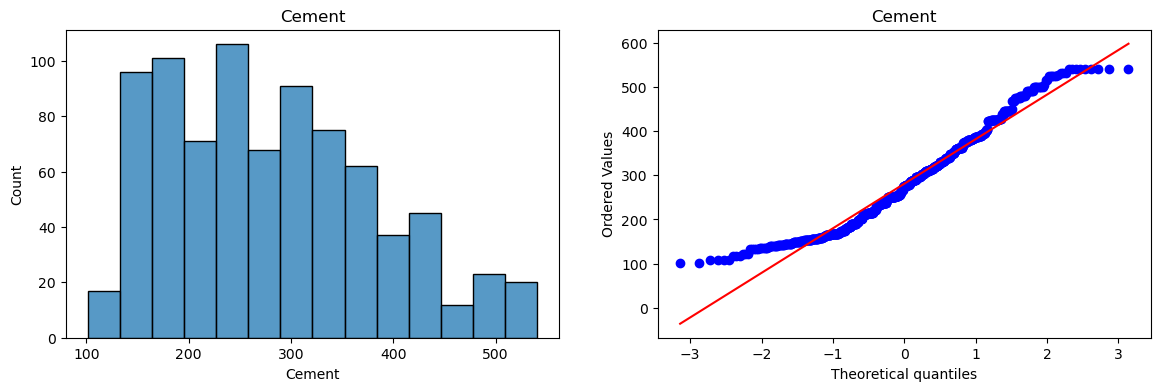

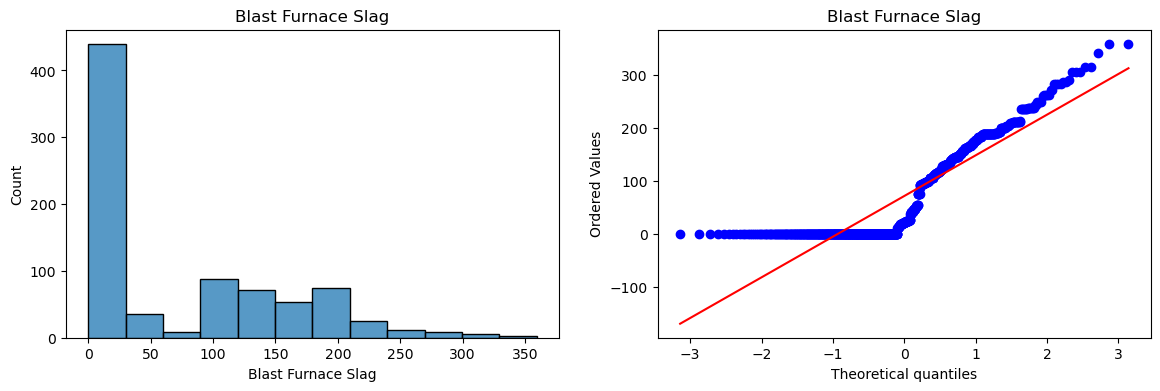

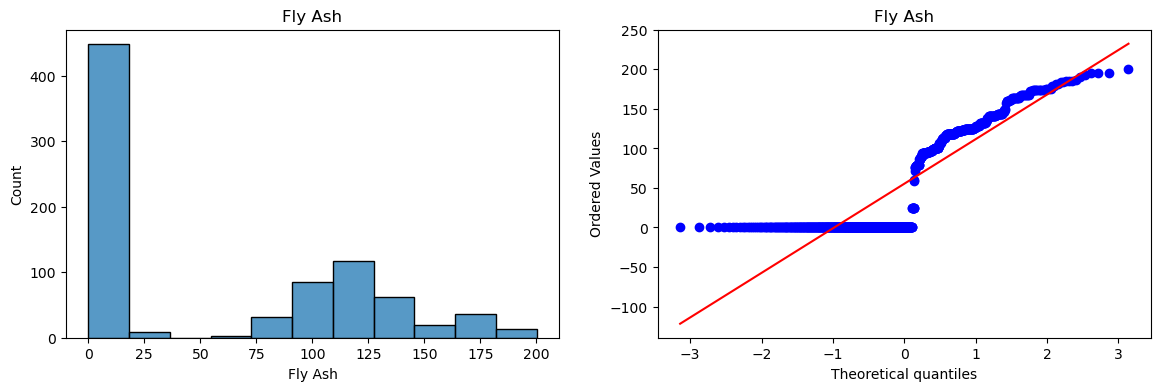

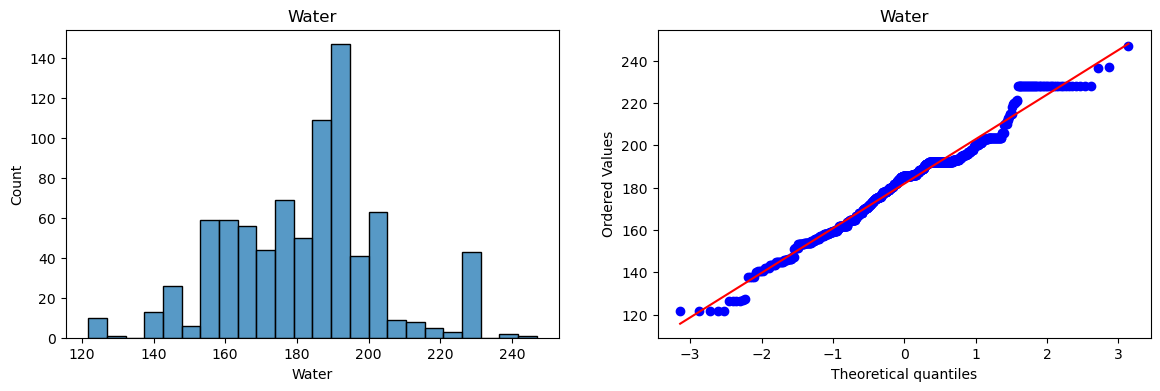

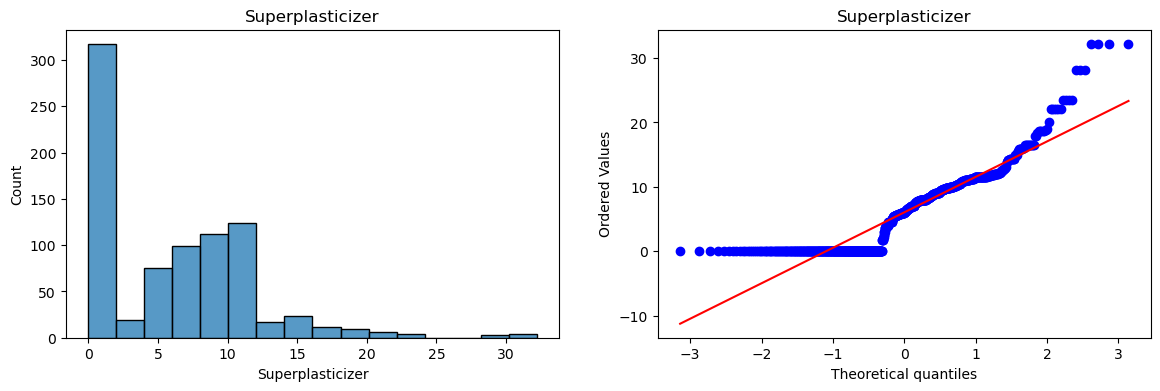

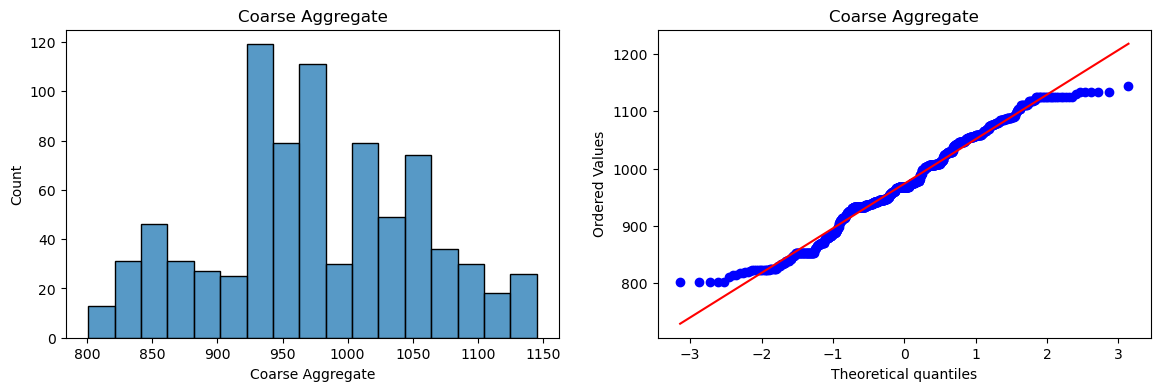

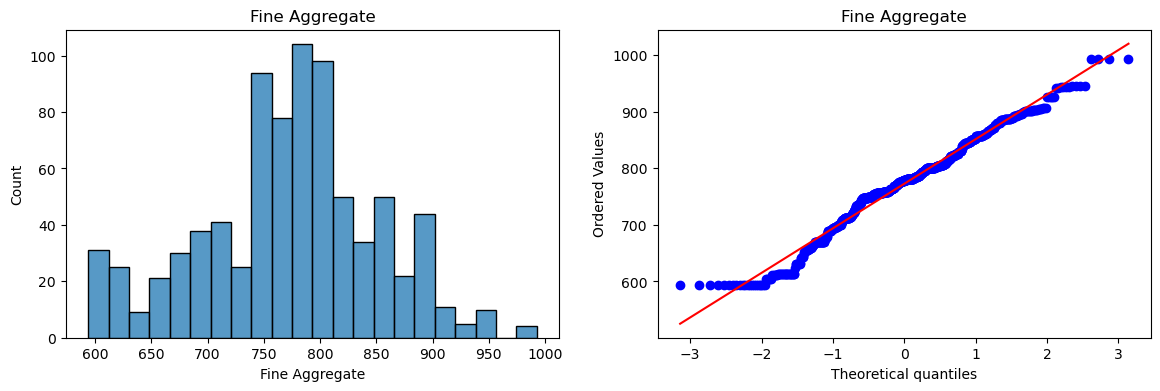

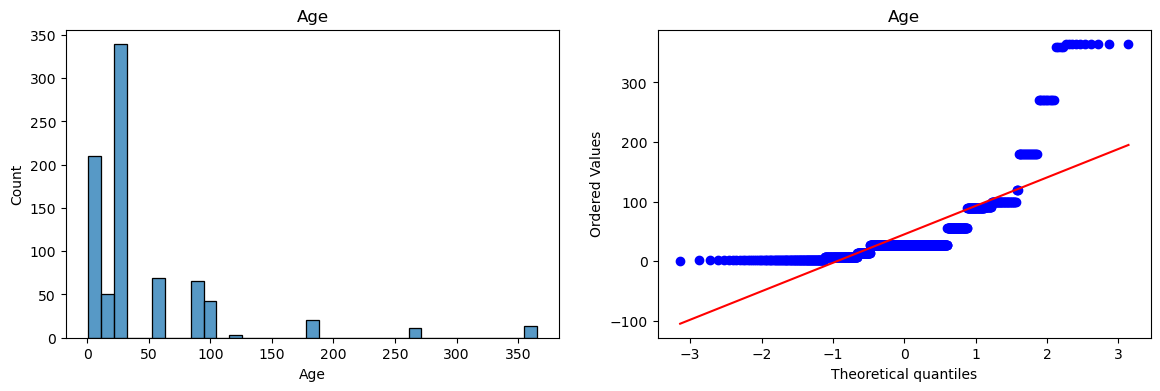

In [ ]:

for col in x_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(x_train[col])
    plt.title(col)
    plt.subplot(122)
    stats.probplot(x_train[col], dist="norm", plot=plt)
    plt.title(col)
    plt.show()
 
# age varies alot

In [ ]:
pw = PowerTransformer(method='box-cox')
x_train_transform = pw.fit_transform(x_train + .000001)
x_test_transform = pw.transform(x_test + .000001)

print( pd.DataFrame({'cols': x_train.columns, 'box_col_lambdas':pw.lambdas_ }))


                 cols  box_col_lambdas
0              Cement         0.196494
1  Blast Furnace Slag         0.022766
2             Fly Ash        -0.028542
3               Water         0.988622
4    Superplasticizer         0.092145
5    Coarse Aggregate         1.106736
6      Fine Aggregate         1.731442
7                 Age         0.052375


In [ ]:
lr = LinearRegression()
lr.fit(x_train_transform, y_train)
y_pred = lr.predict(x_test_transform)

print(r2_score(y_pred, y_test)*100)

78.0117392690491


In [ ]:
pt = PowerTransformer (method='box-cox')
xtransf = pt.fit_transform(x + .000001)

lr = LinearRegression()
print(np.mean(cross_val_score(lr, xtransf, y, scoring='r2')))

0.6662950327179041


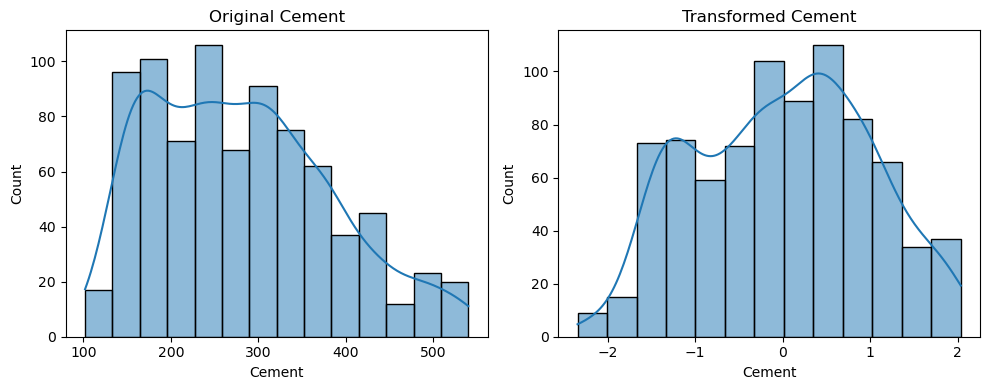

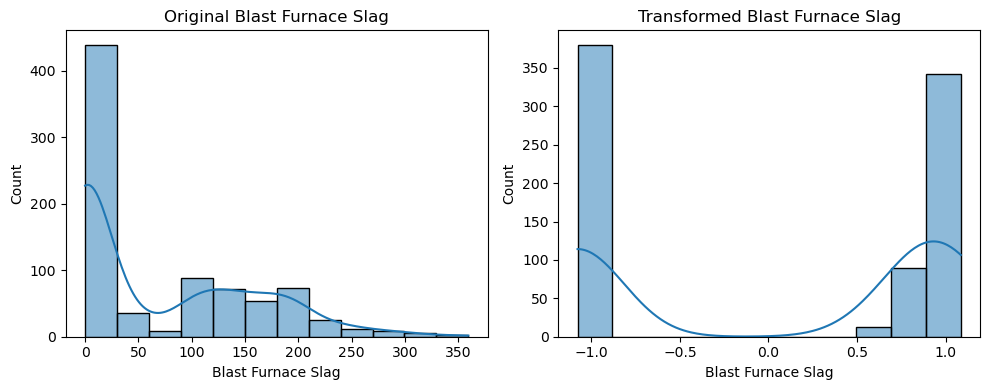

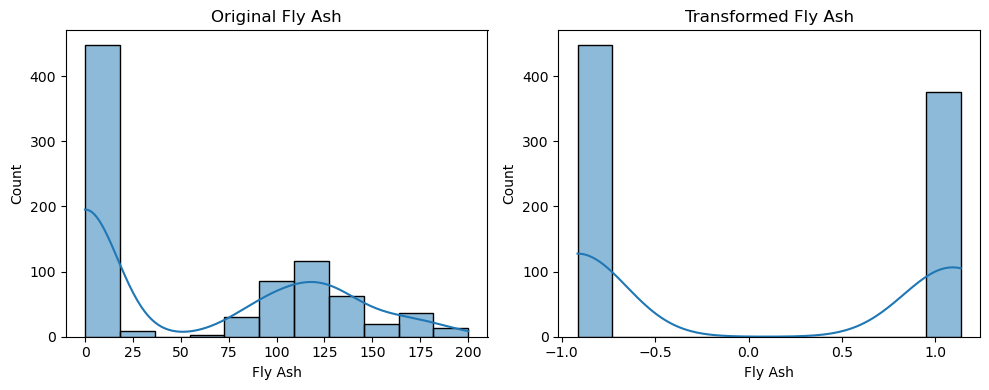

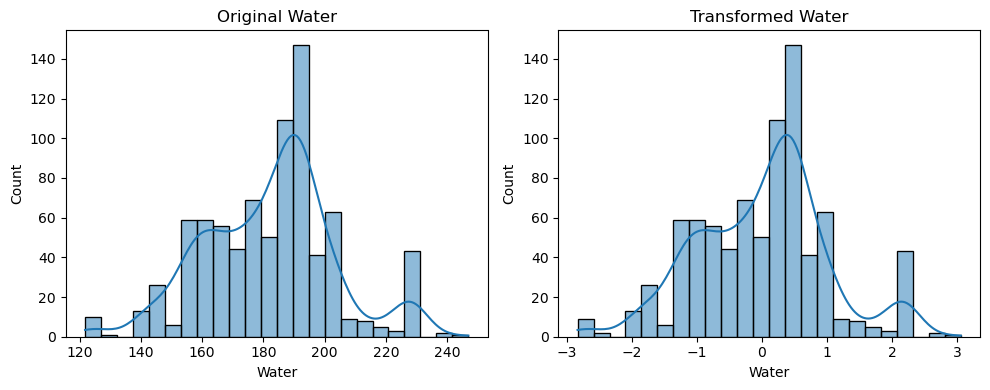

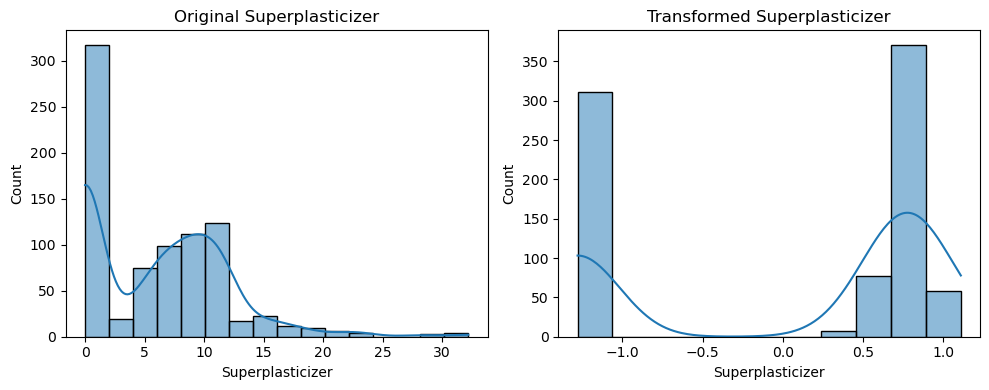

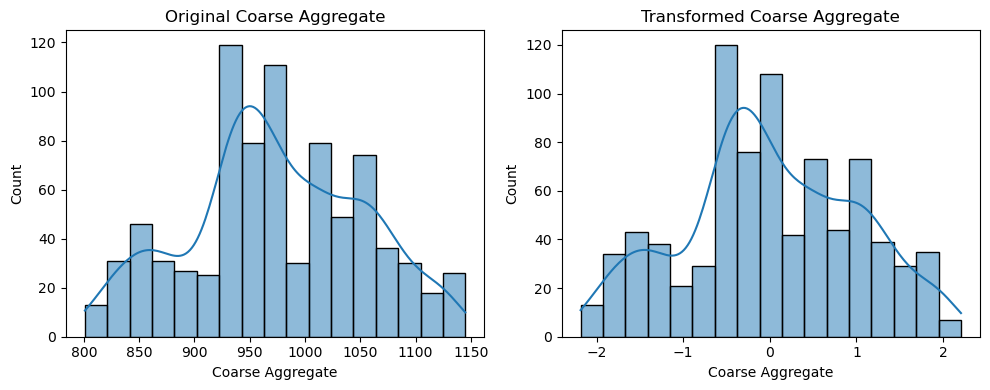

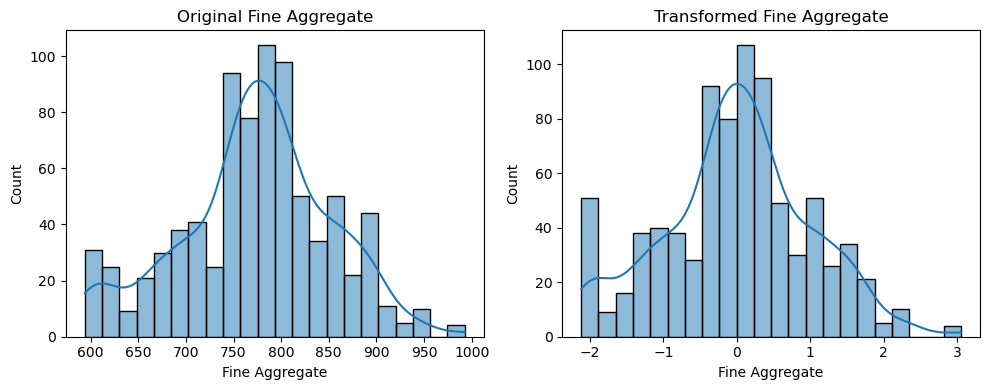

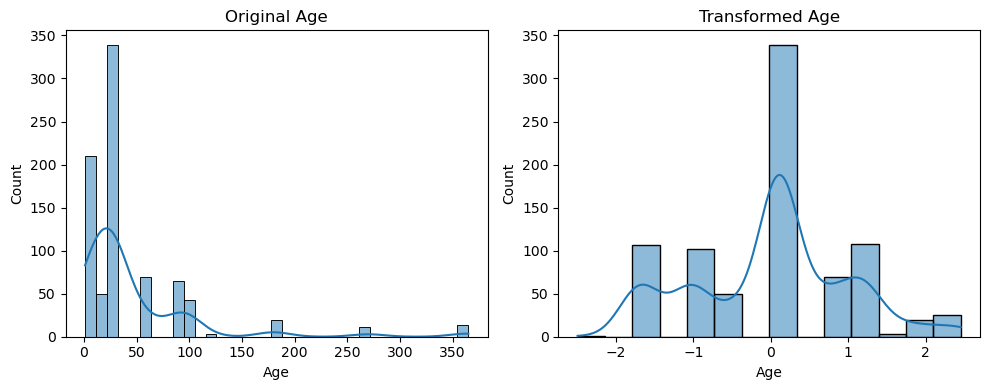

In [ ]:
x_train_transform = pd.DataFrame(x_train_transform, columns=x_train.columns)

for col in x_train_transform.columns:
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(x_train[col], kde=True)
    plt.title(f"Original {col}")

    plt.subplot(1, 2, 2)
    sns.histplot(x_train_transform[col], kde=True)
    plt.title(f"Transformed {col}")

    plt.tight_layout()
    plt.show()

In [ ]:
trf = PowerTransformer(method='yeo-johnson')
x_train_trf = trf.fit_transform(x_train)
x_test_trf = trf.transform(x_test)

lr = LinearRegression()
lr.fit(x_train_trf, y_train)
y_pred = lr.predict(x_test_trf)
print("Accuracy after Jeo_Johnson : ",r2_score(y_test, y_pred)*100)
print("**********************************************************")
print(pd.DataFrame({'Column  ': x_train.columns, 'lambdas of Yeo-Johnson': trf.lambdas_, 'Lambdas of Rok-cok': pw.lambdas_ }))


Accuracy after Jeo_Johnson :  81.62918955213313
**********************************************************
             Column    lambdas of Yeo-Johnson  Lambdas of Rok-cok
0              Cement                0.193866            0.196494
1  Blast Furnace Slag                0.005786            0.022766
2             Fly Ash               -0.120128           -0.028542
3               Water                0.988461            0.988622
4    Superplasticizer                0.241763            0.092145
5    Coarse Aggregate                1.106940            1.106736
6      Fine Aggregate                1.732440            1.731442
7                 Age                0.006058            0.052375
